# PHASE 1: Data Preparation And Exploration

### Load Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("ANIMAL PROJECT/animal_species_200_rows.csv")

In [11]:
df

,Speed,Weight,Lifespan
0,8,349,93
1,32,381,2
2,93,201,32
3,85,21,65
4,40,80,11
...,...,...,...
195,80,164,96
196,85,425,88
197,39,61,9
198,35,145,29


In [3]:
df.head()

,Animal Type,Animal Name,Speed,Weight,Continent,Country,Lifespan,Migration,Reproduction,Threat Level
0,Insect,WalkingStick,8,349,Africa,Australia,93,No,Live,High
1,Bird,Hornbill,32,381,Africa,Brazil,2,Yes,Eggs,Medium
2,Bird,Hornbill,93,201,Europe,Germany,32,Yes,Live,High
3,Bird,Canary,85,21,Europe,Egypt,65,No,Eggs,Critical
4,Mammal,Lemur,40,80,Africa,Brazil,11,Yes,Live,Low


### Data Cleaning

In [5]:
df = df[['Speed', 'Weight', 'Lifespan']]

In [6]:
df = df.dropna()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     200 non-null    int64
 1   Weight    200 non-null    int64
 2   Lifespan  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB


### Correlation Heatmap

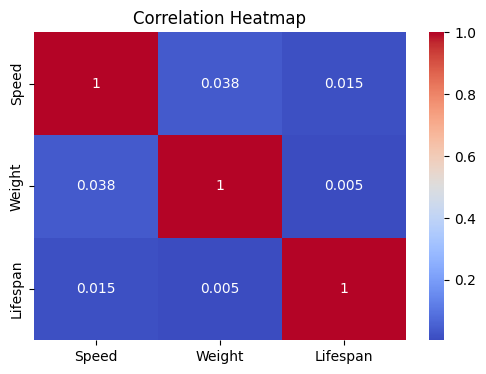

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

 ### Distribution Chart 

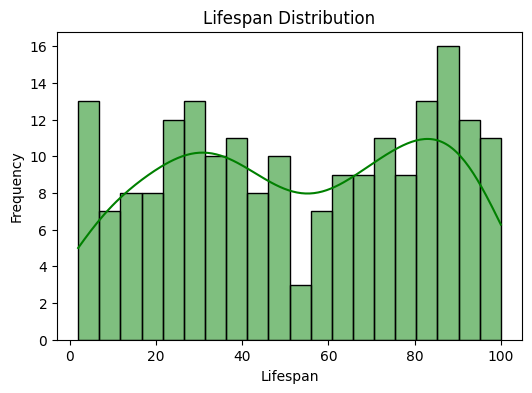

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df['Lifespan'], bins=20, kde=True, color='green')
plt.title("Lifespan Distribution")
plt.xlabel("Lifespan")
plt.ylabel("Frequency")
plt.show()

# PHASE 2: Linear Regression Model

### Split Data

In [10]:
X = df[['Speed', 'Weight']]
y = df['Lifespan']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
    


### Train Linear Model

In [12]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Intercept & Coefficients

In [13]:
print("Intercept:", linear_model.intercept_)
print("Coefficients:", linear_model.coef_)

Intercept: 55.769193118983964
Coefficients: [-0.04059099 -0.00321137]


# PHASE 3: Polynomial Model

### Transform Data

In [14]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

### Train Polynomial Model

In [15]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# PHASE 4: Accuracy Report

### R² Score

In [16]:
from sklearn.metrics import r2_score
y_pred_linear = linear_model.predict(X_test)
y_pred_poly = poly_model.predict(X_test_poly)
r2_linear = r2_score(y_test, y_pred_linear)
r2_poly = r2_score(y_test, y_pred_poly)
print("Linear R²:", r2_linear)
print("Polynomial R²:", r2_poly)

Linear R²: -0.030494006008734864
Polynomial R²: -0.08828935447502717


### Scatter Plot

C:\Users\Hp\AppData\Local\Temp\ipykernel_4012\1668532171.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],


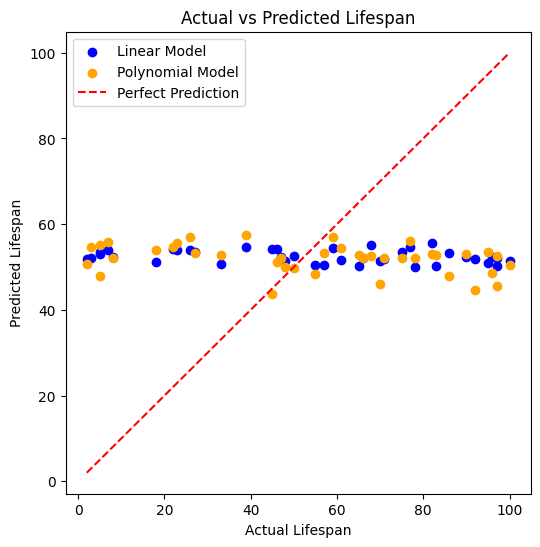

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_linear, color='blue', label="Linear Model")
plt.scatter(y_test, y_pred_poly, color='orange', label="Polynomial Model")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', color='red', label="Perfect Prediction")
plt.xlabel("Actual Lifespan")
plt.ylabel("Predicted Lifespan")
plt.legend()
plt.title("Actual vs Predicted Lifespan")
plt.show()

# PHASE 5: Saving For Deployment

In [19]:
import pickle

In [20]:
with open("linear_model.pkl", "wb") as f:
    pickle.dump(linear_model, f)
with open("poly_model.pkl", "wb") as f:
    pickle.dump(poly_model, f)
with open("poly_converter.pkl", "wb") as f:
    pickle.dump(poly, f)